In [1]:
import random
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights,
)


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [3]:
DATA_DIR = "./data"
BATCH_SIZE = 64
NUM_WORKERS = 2

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
CHECKPOINT_DIR = ARTIFACTS_DIR / "checkpoints"

ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
def save_checkpoint(path, model, optimizer, epoch, best_val_acc, history):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    history = checkpoint["history"]
    return start_epoch, best_val_acc, history


In [5]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5)),
])

aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5)),
])

weights_resnet = ResNet18_Weights.DEFAULT
resnet_preprocess = weights_resnet.transforms()
print(resnet_preprocess)


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [6]:
train_full_basic = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=True,
    transform=basic_transform,
)
test_basic = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=True,
    transform=basic_transform,
)

train_size = int(0.8 * len(train_full_basic))
val_size = len(train_full_basic) - train_size

train_basic, val_basic = random_split(
    train_full_basic,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

print("train_basic:", len(train_basic))
print("val_basic:", len(val_basic))
print("test_basic:", len(test_basic))


100%|██████████| 2.64G/2.64G [00:24<00:00, 107MB/s]


train_basic: 4000
val_basic: 1000
test_basic: 8000


In [7]:
train_full_aug = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=aug_transform,
)
train_aug, _ = random_split(
    train_full_aug,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_full_resnet = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=resnet_preprocess,
)
test_resnet = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=False,
    transform=resnet_preprocess,
)
train_resnet, val_resnet = random_split(
    train_full_resnet,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)


In [8]:
train_loader_base = DataLoader(
    train_basic,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
train_loader_aug = DataLoader(
    train_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader_base = DataLoader(
    val_basic,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader_base = DataLoader(
    test_basic,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

train_loader_resnet = DataLoader(
    train_resnet,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader_resnet = DataLoader(
    val_resnet,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader_resnet = DataLoader(
    test_resnet,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


In [9]:
x, y = next(iter(train_loader_base))
print("Batch size:", train_loader_base.batch_size)
print("x.shape:", x.shape)
print("y.shape:", y.shape)
print("x dtype:", x.dtype)
print("y dtype:", y.dtype)

x = x.to(device)
y = y.to(device)
print("x.device:", x.device)
print("y.device:", y.device)


Batch size: 64
x.shape: torch.Size([64, 3, 96, 96])
y.shape: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64
x.device: cpu
y.device: cpu


['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


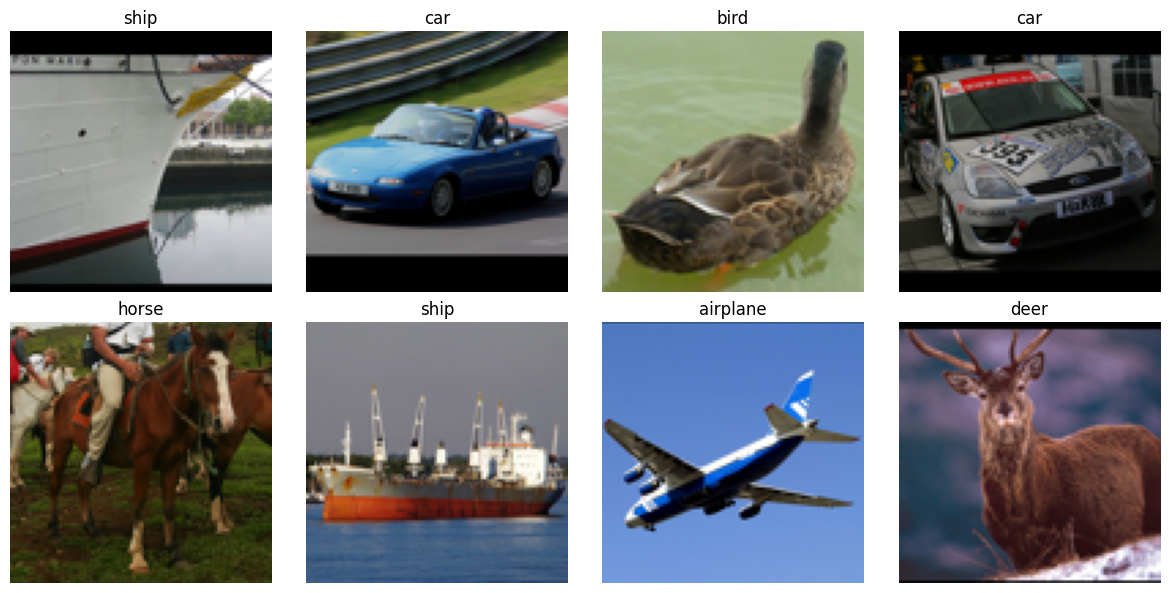

In [10]:
# функция для обратной нормализации (mean=0.5, std=0.5)
def denorm(img):
    img = img * 0.5 + 0.5   # вернуть диапазон [0,1]
    return img.clamp(0, 1)

classes = train_full_basic.classes
print(classes)

x_vis, y_vis = next(iter(val_loader_base))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = denorm(x_vis[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(classes[y_vis[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()



In [11]:
class PetSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, image_transform=None,
                 mask_transform=None, download=False):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download,
        )
        self.image_transform = image_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]
        if self.image_transform is not None:
            image = self.image_transform(image)
        if self.mask_transform is not None:
            mask = self.mask_transform(mask)
        return image, mask


In [12]:
image_transform_seg = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

mask_transform_seg = transforms.Compose([
    transforms.Resize((224, 224),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])


In [13]:
train_pet = PetSegmentationDataset(
    root=DATA_DIR,
    split="trainval",
    image_transform=image_transform_seg,
    mask_transform=mask_transform_seg,
    download=True,
)
test_pet = PetSegmentationDataset(
    root=DATA_DIR,
    split="test",
    image_transform=image_transform_seg,
    mask_transform=mask_transform_seg,
    download=True,
)

train_size_pet = int(0.8 * len(train_pet))
val_size_pet = len(train_pet) - train_size_pet

train_pet_ds, val_pet_ds = random_split(
    train_pet,
    [train_size_pet, val_size_pet],
    generator=torch.Generator().manual_seed(SEED),
)

print("train_pet:", len(train_pet_ds))
print("val_pet:", len(val_pet_ds))
print("test_pet:", len(test_pet))


100%|██████████| 792M/792M [00:33<00:00, 23.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.4MB/s]


train_pet: 2944
val_pet: 736
test_pet: 3669


In [14]:
train_pet_loader = DataLoader(
    train_pet_ds,
    batch_size=16,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_pet_loader = DataLoader(
    val_pet_ds,
    batch_size=16,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_pet_loader = DataLoader(
    test_pet,
    batch_size=16,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


In [15]:
x_seg, y_seg = next(iter(train_pet_loader))
print("Batch size:", train_pet_loader.batch_size)
print("x_seg.shape:", x_seg.shape)
print("y_seg.shape:", y_seg.shape)
print("x_seg dtype:", x_seg.dtype)
print("y_seg dtype:", y_seg.dtype)

x_seg = x_seg.to(device)
y_seg = y_seg.to(device)
print("x_seg.device:", x_seg.device)
print("y_seg.device:", y_seg.device)


Batch size: 16
x_seg.shape: torch.Size([16, 3, 224, 224])
y_seg.shape: torch.Size([16, 1, 224, 224])
x_seg dtype: torch.float32
y_seg dtype: torch.uint8
x_seg.device: cpu
y_seg.device: cpu


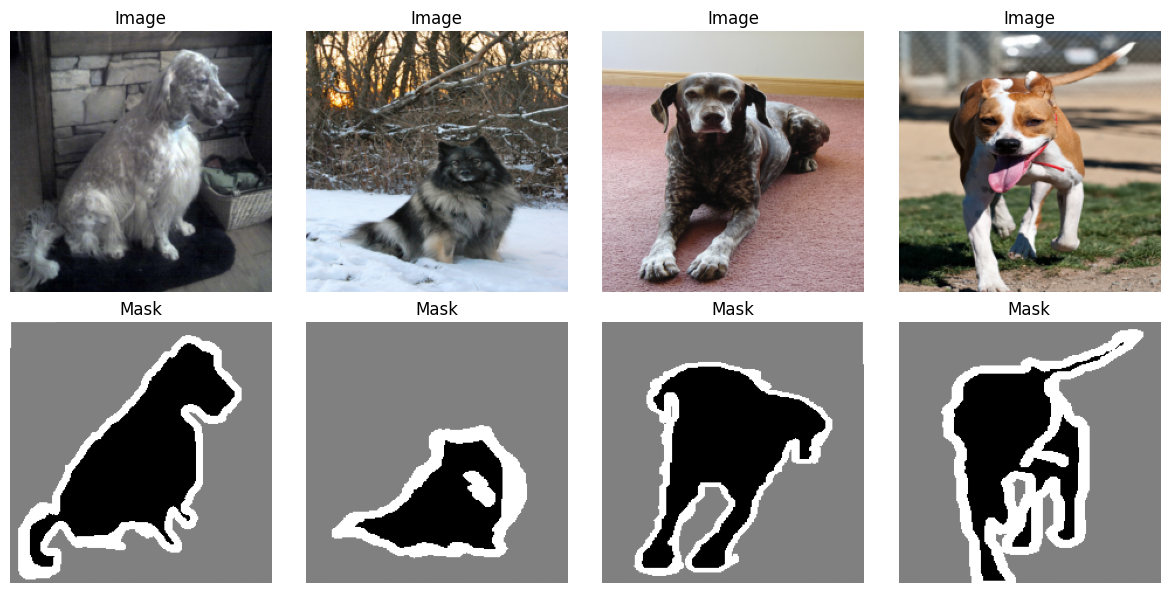

In [16]:
x_seg_vis, y_seg_vis = next(iter(train_pet_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    img = x_seg_vis[i].permute(1, 2, 0).numpy()
    mask = y_seg_vis[i].squeeze(0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title("Mask")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


In [17]:
model_tmp = resnet18(weights=ResNet18_Weights.DEFAULT)
model_tmp.fc = nn.Linear(model_tmp.fc.in_features, 10)
model_tmp = model_tmp.to(device)

xb, yb = next(iter(train_loader_resnet))
xb = xb.to(device)
yb = yb.to(device)
out = model_tmp(xb)

print("Model device:", next(model_tmp.parameters()).device)
print("Batch device:", xb.device)
print("Output device:", out.device)
del model_tmp, xb, yb, out
torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 287MB/s]


Model device: cpu
Batch device: cpu
Output device: cpu


In [18]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += yb.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc


In [20]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += yb.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc


In [21]:
import copy

def fit_classifier(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    checkpoint_path=None,
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    start_epoch = 1

    if checkpoint_path is not None and Path(checkpoint_path).exists():
        print(f"Loading checkpoint from {checkpoint_path}")
        start_epoch, best_val_acc, history = load_checkpoint(
            checkpoint_path, model, optimizer, device
        )
        best_state = copy.deepcopy(model.state_dict())
        print(f"Resuming from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if checkpoint_path is not None:
            save_checkpoint(
                checkpoint_path,
                model,
                optimizer,
                epoch,
                best_val_acc,
                history,
            )

    model.load_state_dict(best_state)

    return {
        "history": history,
        "best_state": best_state,
        "best_val_acc": best_val_acc,
    }


In [22]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 96 -> 48

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 48 -> 24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 24 -> 12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [23]:
def build_resnet18_head_only(num_classes=10):
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def build_resnet18_finetune(num_classes=10):
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def make_optimizer(model, lr=1e-3, weight_decay=1e-4):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)


In [24]:
criterion = nn.CrossEntropyLoss()

# C1: SimpleCNN base
C1_EPOCHS = 10
C1_LR = 1e-3

model_c1 = SimpleCNN(num_classes=10).to(device)
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=C1_LR)

result_c1 = fit_classifier(
    model=model_c1,
    train_loader=train_loader_base,
    val_loader=val_loader_base,
    criterion=criterion,
    optimizer=optimizer_c1,
    device=device,
    epochs=C1_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / "c1_last.pt",
)


Epoch 01/10 | train_loss=2.2034 train_acc=0.1573 | val_loss=2.0359 val_acc=0.2380
Epoch 02/10 | train_loss=1.9444 train_acc=0.2442 | val_loss=1.8409 val_acc=0.2640
Epoch 03/10 | train_loss=1.7813 train_acc=0.2722 | val_loss=1.7033 val_acc=0.3000
Epoch 04/10 | train_loss=1.6981 train_acc=0.2980 | val_loss=1.6588 val_acc=0.3160
Epoch 05/10 | train_loss=1.6811 train_acc=0.3050 | val_loss=1.6108 val_acc=0.3420
Epoch 06/10 | train_loss=1.6374 train_acc=0.3195 | val_loss=1.6654 val_acc=0.3160
Epoch 07/10 | train_loss=1.6327 train_acc=0.3365 | val_loss=1.5931 val_acc=0.3350
Epoch 08/10 | train_loss=1.6057 train_acc=0.3498 | val_loss=1.5685 val_acc=0.3650
Epoch 09/10 | train_loss=1.5794 train_acc=0.3528 | val_loss=1.5479 val_acc=0.3690
Epoch 10/10 | train_loss=1.5639 train_acc=0.3640 | val_loss=1.5406 val_acc=0.3900


In [25]:
# C2: SimpleCNN + augmentations
C2_EPOCHS = 10
C2_LR = 1e-3

model_c2 = SimpleCNN(num_classes=10).to(device)
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=C2_LR)

result_c2 = fit_classifier(
    model=model_c2,
    train_loader=train_loader_aug,
    val_loader=val_loader_base,
    criterion=criterion,
    optimizer=optimizer_c2,
    device=device,
    epochs=C2_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / "c2_last.pt",
)


Epoch 01/10 | train_loss=2.2502 train_acc=0.1445 | val_loss=2.1311 val_acc=0.2320
Epoch 02/10 | train_loss=2.0517 train_acc=0.2318 | val_loss=1.9529 val_acc=0.2600
Epoch 03/10 | train_loss=1.8634 train_acc=0.2620 | val_loss=1.7170 val_acc=0.3130
Epoch 04/10 | train_loss=1.7477 train_acc=0.2925 | val_loss=1.6385 val_acc=0.3220
Epoch 05/10 | train_loss=1.7108 train_acc=0.2985 | val_loss=1.6884 val_acc=0.2940
Epoch 06/10 | train_loss=1.6865 train_acc=0.3230 | val_loss=1.5972 val_acc=0.3520
Epoch 07/10 | train_loss=1.6622 train_acc=0.3207 | val_loss=1.5986 val_acc=0.3330
Epoch 08/10 | train_loss=1.6486 train_acc=0.3350 | val_loss=1.5540 val_acc=0.3600
Epoch 09/10 | train_loss=1.6291 train_acc=0.3443 | val_loss=1.5763 val_acc=0.3580
Epoch 10/10 | train_loss=1.6117 train_acc=0.3473 | val_loss=1.5167 val_acc=0.3740


In [27]:
# C3: ResNet18 head-only
C3_EPOCHS = 6
C3_LR = 1e-3

model_c3 = build_resnet18_head_only(num_classes=10).to(device)
optimizer_c3 = make_optimizer(model_c3, lr=C3_LR)

result_c3 = fit_classifier(
    model=model_c3,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion,
    optimizer=optimizer_c3,
    device=device,
    epochs=C3_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / "c3_last.pt",
)


Epoch 01/6 | train_loss=1.0611 train_acc=0.7408 | val_loss=0.4600 val_acc=0.9110
Epoch 02/6 | train_loss=0.3782 train_acc=0.9207 | val_loss=0.3222 val_acc=0.9150
Epoch 03/6 | train_loss=0.2762 train_acc=0.9330 | val_loss=0.2740 val_acc=0.9150
Epoch 04/6 | train_loss=0.2265 train_acc=0.9435 | val_loss=0.2456 val_acc=0.9360
Epoch 05/6 | train_loss=0.1984 train_acc=0.9490 | val_loss=0.2333 val_acc=0.9320
Epoch 06/6 | train_loss=0.1767 train_acc=0.9540 | val_loss=0.2190 val_acc=0.9340


In [28]:
# C4: ResNet18 partial finetune (layer4 + fc)
C4_EPOCHS = 6
C4_LR = 1e-4

model_c4 = build_resnet18_finetune(num_classes=10).to(device)
optimizer_c4 = make_optimizer(model_c4, lr=C4_LR)

result_c4 = fit_classifier(
    model=model_c4,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion,
    optimizer=optimizer_c4,
    device=device,
    epochs=C4_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / "c4_last.pt",
)


Epoch 01/6 | train_loss=0.6620 train_acc=0.8165 | val_loss=0.2622 val_acc=0.9240
Epoch 02/6 | train_loss=0.1281 train_acc=0.9742 | val_loss=0.2137 val_acc=0.9350
Epoch 03/6 | train_loss=0.0477 train_acc=0.9975 | val_loss=0.2004 val_acc=0.9400
Epoch 04/6 | train_loss=0.0206 train_acc=0.9998 | val_loss=0.1988 val_acc=0.9390
Epoch 05/6 | train_loss=0.0119 train_acc=1.0000 | val_loss=0.1894 val_acc=0.9410
Epoch 06/6 | train_loss=0.0083 train_acc=1.0000 | val_loss=0.1945 val_acc=0.9400


In [29]:
classification_results = {
    "C1": {
        "model": model_c1,
        "result": result_c1,
        "model_summary": "SimpleCNN base",
    },
    "C2": {
        "model": model_c2,
        "result": result_c2,
        "model_summary": "SimpleCNN aug",
    },
    "C3": {
        "model": model_c3,
        "result": result_c3,
        "model_summary": "ResNet18 pretrained head-only",
    },
    "C4": {
        "model": model_c4,
        "result": result_c4,
        "model_summary": "ResNet18 pretrained layer4+fc finetune",
    },
}

best_exp_id = max(
    classification_results,
    key=lambda k: classification_results[k]["result"]["best_val_acc"],
)
best_info = classification_results[best_exp_id]
best_model = best_info["model"]
best_model.load_state_dict(best_info["result"]["best_state"])

print("Best experiment:", best_exp_id)
print("Best val accuracy:", best_info["result"]["best_val_acc"])


Best experiment: C4
Best val accuracy: 0.941


In [30]:
if best_exp_id in ["C1", "C2"]:
    best_test_loader = test_loader_base
else:
    best_test_loader = test_loader_resnet

test_loss_best, test_acc_best = evaluate(
    best_model,
    best_test_loader,
    criterion,
    device,
)
print("Best test accuracy:", test_acc_best)


Best test accuracy: 0.948


In [31]:
torch.save(
    best_model.state_dict(),
    ARTIFACTS_DIR / "best_classifier.pt",
)
print("Saved best model to artifacts/best_classifier.pt")


Saved best model to artifacts/best_classifier.pt


In [49]:
# Определяем архитектуру, trainable parts и lr
if best_exp_id == "C1":
    architecture = "SimpleCNN"
    trainable_parts = "all"
    lr_used = C1_LR
    transforms_used = "basic_transform"
    preprocess_used = "none"
    augmentation_used = "none"

elif best_exp_id == "C2":
    architecture = "SimpleCNN"
    trainable_parts = "all"
    lr_used = C2_LR
    transforms_used = "basic_transform"
    preprocess_used = "none"
    augmentation_used = "RandomHorizontalFlip + RandomCrop + ColorJitter"

elif best_exp_id == "C3":
    architecture = "ResNet18 pretrained"
    trainable_parts = "fc only"
    lr_used = C3_LR
    transforms_used = "resnet_preprocess"
    preprocess_used = "ResNet18_Weights.DEFAULT.transforms()"
    augmentation_used = "none"

elif best_exp_id == "C4":
    architecture = "ResNet18 pretrained"
    trainable_parts = "layer4 + fc"
    lr_used = C4_LR
    transforms_used = "resnet_preprocess"
    preprocess_used = "ResNet18_Weights.DEFAULT.transforms()"
    augmentation_used = "none"

best_config = {
    "dataset": "STL10",
    "best_experiment_id": best_exp_id,
    "seed": SEED,
    "criterion": "CrossEntropyLoss",
    "test_loader_used_once": True,
    "architecture": architecture,
    "transforms": transforms_used,
    "preprocess": preprocess_used,
    "augmentation": augmentation_used,
    "optimizer": "Adam",
    "lr": lr_used,
    "epochs": len(best_info["result"]["history"]["train_loss"]),
    "trainable_parts": trainable_parts
}

with open(ARTIFACTS_DIR / "best_classifier_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

print("Saved updated config → artifacts/best_classifier_config.json")



Saved updated config → artifacts/best_classifier_config.json


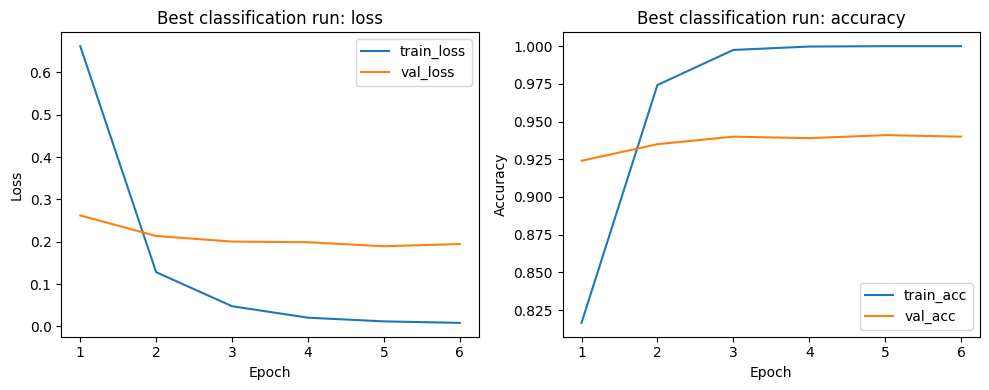

In [33]:
best_history = best_info["result"]["history"]
epochs_range = range(1, len(best_history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, best_history["train_loss"], label="train_loss")
plt.plot(epochs_range, best_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best classification run: loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, best_history["train_acc"], label="train_acc")
plt.plot(epochs_range, best_history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best classification run: accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150)
plt.show()


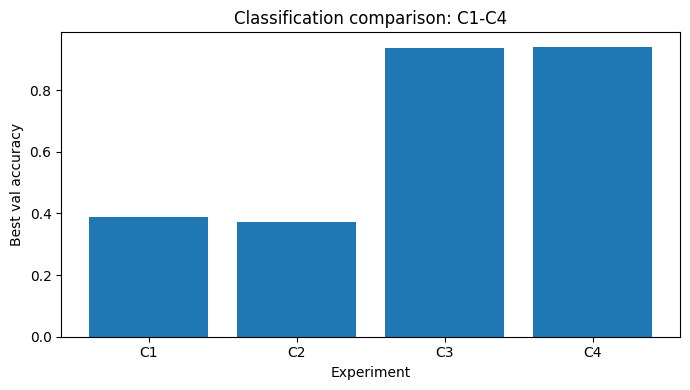

In [34]:
exp_ids = ["C1", "C2", "C3", "C4"]
val_scores = [
    classification_results[e]["result"]["best_val_acc"] for e in exp_ids
]

plt.figure(figsize=(7, 4))
plt.bar(exp_ids, val_scores)
plt.xlabel("Experiment")
plt.ylabel("Best val accuracy")
plt.title("Classification comparison: C1-C4")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=150)
plt.show()


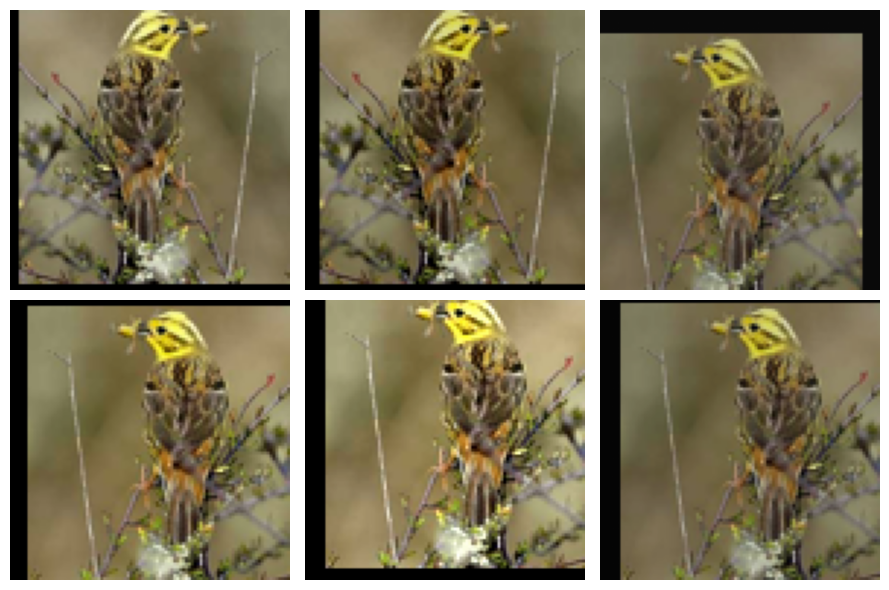

In [35]:
# функция обратной нормализации
def denorm(img):
    return img * 0.5 + 0.5   # вернуть диапазон [0,1]

raw_stl = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=None,
)

img, label = raw_stl[0]
aug_examples = [aug_transform(img) for _ in range(6)]

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

for ax, aug_img in zip(axes, aug_examples):
    img_vis = denorm(aug_img).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img_vis)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=150)
plt.show()



In [36]:
seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=seg_weights).to(device)
seg_model.eval()
print(seg_model.__class__.__name__)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 498MB/s]


DeepLabV3


In [37]:
def compute_iou(pred_mask, true_mask, eps=1e-6):
    # pred_mask, true_mask: (H, W) bool / 0-1
    intersection = (pred_mask & true_mask).sum().item()
    union = (pred_mask | true_mask).sum().item()
    if union == 0:
        return 1.0
    return intersection / (union + eps)


def compute_pixel_precision_recall(pred_mask, true_mask, eps=1e-6):
    tp = (pred_mask & true_mask).sum().item()
    fp = (pred_mask & (~true_mask)).sum().item()
    fn = ((~pred_mask) & true_mask).sum().item()

    precision = tp / (tp + fp + eps) if (tp + fp) > 0 else 1.0
    recall = tp / (tp + fn + eps) if (tp + fn) > 0 else 1.0
    return precision, recall


In [38]:
@torch.no_grad()
def evaluate_segmentation(
    model,
    loader,
    device,
    threshold=0.5,
    max_batches=None,
):
    model.eval()
    ious = []
    precisions = []
    recalls = []

    for b_idx, (images, masks) in enumerate(loader):
        images = images.to(device)
        masks = masks.to(device)  # (B, 1, H, W), uint8

        outputs = model(images)["out"]  # (B, C, H, W)
        # берём канал "foreground": для простоты возьмём argmax по каналам
        # и считаем foreground = (pred_class > 0)
        probs = torch.softmax(outputs, dim=1)
        # вероятность "не фон" = 1 - p_background
        p_background = probs[:, 0, :, :]
        p_foreground = 1.0 - p_background
        pred_bin = (p_foreground > threshold)  # (B, H, W)

        true_bin = (masks.squeeze(1) > 0)  # (B, H, W)

        for i in range(images.size(0)):
            pm = pred_bin[i]
            tm = true_bin[i]
            iou = compute_iou(pm, tm)
            prec, rec = compute_pixel_precision_recall(pm, tm)
            ious.append(iou)
            precisions.append(prec)
            recalls.append(rec)

        if max_batches is not None and (b_idx + 1) >= max_batches:
            break

    mean_iou = float(np.mean(ious)) if ious else 0.0
    mean_precision = float(np.mean(precisions)) if precisions else 0.0
    mean_recall = float(np.mean(recalls)) if recalls else 0.0
    return mean_iou, mean_precision, mean_recall


In [39]:
# V1: базовая постобработка (threshold=0.5)
V1_THRESHOLD = 0.5
mean_iou_v1, precision_v1, recall_v1 = evaluate_segmentation(
    seg_model,
    val_pet_loader,
    device,
    threshold=V1_THRESHOLD,
    max_batches=20,  # можно убрать ограничение
)
print("V1 (threshold=0.5):")
print("mean_iou:", mean_iou_v1)
print("precision:", precision_v1)
print("recall:", recall_v1)


V1 (threshold=0.5):
mean_iou: 0.3882022779737683
precision: 0.9999999999143331
recall: 0.3882022779737683


In [40]:
# V2: альтернативная постобработка (threshold=0.7)
V2_THRESHOLD = 0.7
mean_iou_v2, precision_v2, recall_v2 = evaluate_segmentation(
    seg_model,
    val_pet_loader,
    device,
    threshold=V2_THRESHOLD,
    max_batches=20,
)
print("V2 (threshold=0.7):")
print("mean_iou:", mean_iou_v2)
print("precision:", precision_v2)
print("recall:", recall_v2)


V2 (threshold=0.7):
mean_iou: 0.331440080908573
precision: 0.9999999959651742
recall: 0.331440080908573


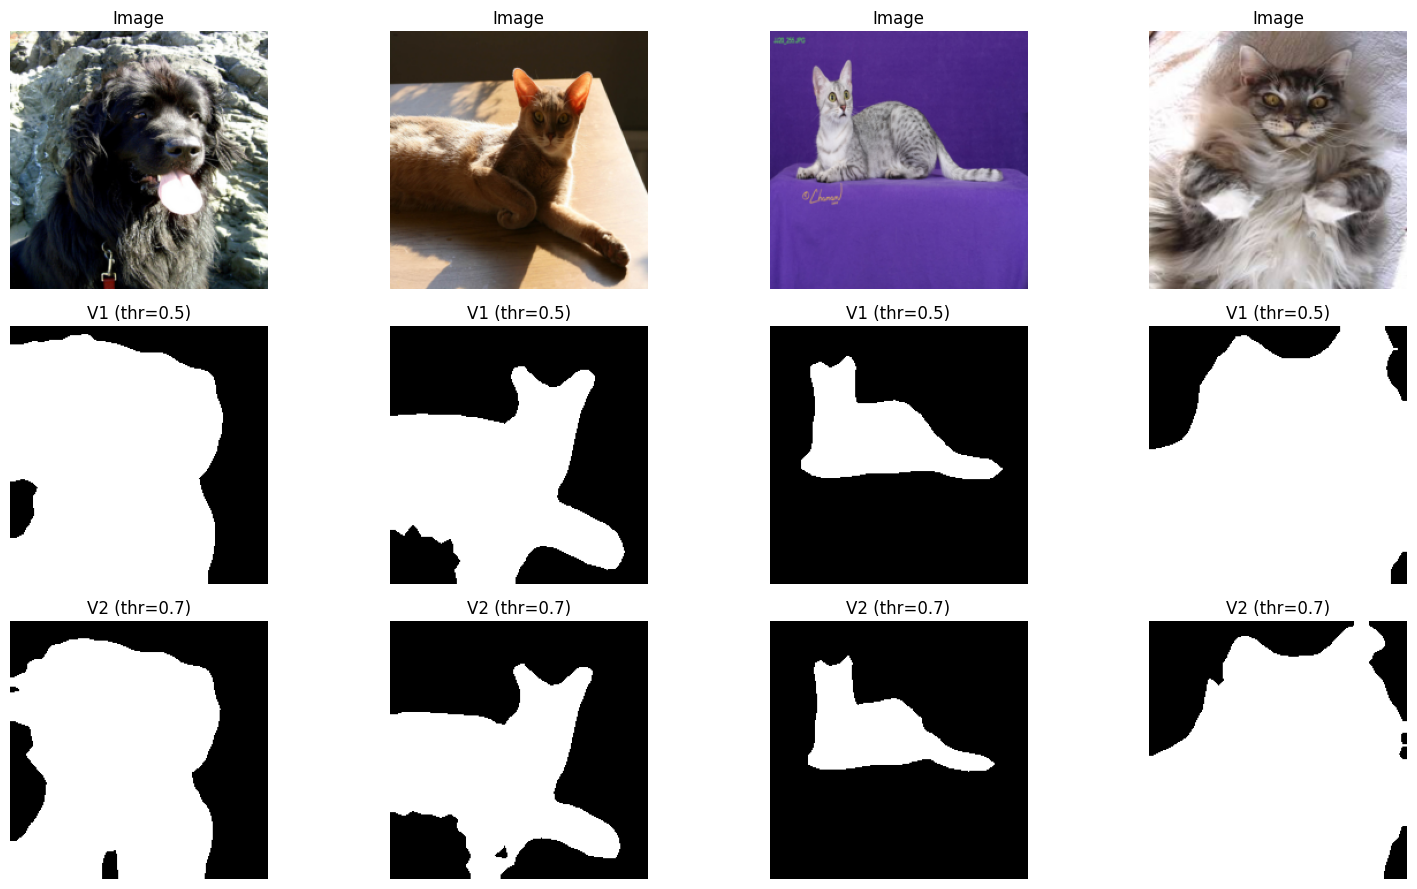

In [41]:
import matplotlib.pyplot as plt

@torch.no_grad()
def compare_segmentation_examples(model, loader, device, thr_v1=0.5, thr_v2=0.7, n=4):
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(device), masks.to(device)

    out = model(imgs)["out"]
    probs = torch.softmax(out, dim=1)
    p_fg = 1 - probs[:, 0, :, :]

    pred_v1 = (p_fg > thr_v1)
    pred_v2 = (p_fg > thr_v2)
    true = (masks.squeeze(1) > 0)

    fig, ax = plt.subplots(3, n, figsize=(4*n, 9))

    for i in range(n):
        ax[0, i].imshow(imgs[i].cpu().permute(1, 2, 0))
        ax[0, i].set_title("Image")
        ax[0, i].axis("off")

        ax[1, i].imshow(pred_v1[i].cpu(), cmap="gray")
        ax[1, i].set_title("V1 (thr=0.5)")
        ax[1, i].axis("off")

        ax[2, i].imshow(pred_v2[i].cpu(), cmap="gray")
        ax[2, i].set_title("V2 (thr=0.7)")
        ax[2, i].axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "segmentation_examples.png", dpi=150)
    plt.show()

# запуск
compare_segmentation_examples(seg_model, val_pet_loader, device)


In [42]:
@torch.no_grad()
def visualize_segmentation_examples(model, loader, device, threshold, n_batches=1):
    model.eval()
    images_vis = []
    preds_vis = []
    masks_vis = []

    for b_idx, (images, masks) in enumerate(loader):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)["out"]
        probs = torch.softmax(outputs, dim=1)
        p_background = probs[:, 0, :, :]
        p_foreground = 1.0 - p_background
        pred_bin = (p_foreground > threshold)

        true_bin = (masks.squeeze(1) > 0)

        for i in range(images.size(0)):
            images_vis.append(images[i].cpu())
            preds_vis.append(pred_bin[i].cpu())
            masks_vis.append(true_bin[i].cpu())

        if (b_idx + 1) >= n_batches:
            break

    n = min(4, len(images_vis))
    fig, axes = plt.subplots(3, n, figsize=(4 * n, 9))
    for i in range(n):
        img = images_vis[i].permute(1, 2, 0).numpy()
        axes[0, i].imshow(img)
        axes[0, i].set_title("Image")
        axes[0, i].axis("off")

        axes[1, i].imshow(masks_vis[i].numpy(), cmap="gray")
        axes[1, i].set_title("GT mask")
        axes[1, i].axis("off")

        axes[2, i].imshow(preds_vis[i].numpy(), cmap="gray")
        axes[2, i].set_title("Pred mask")
        axes[2, i].axis("off")

    plt.tight_layout()
    return fig


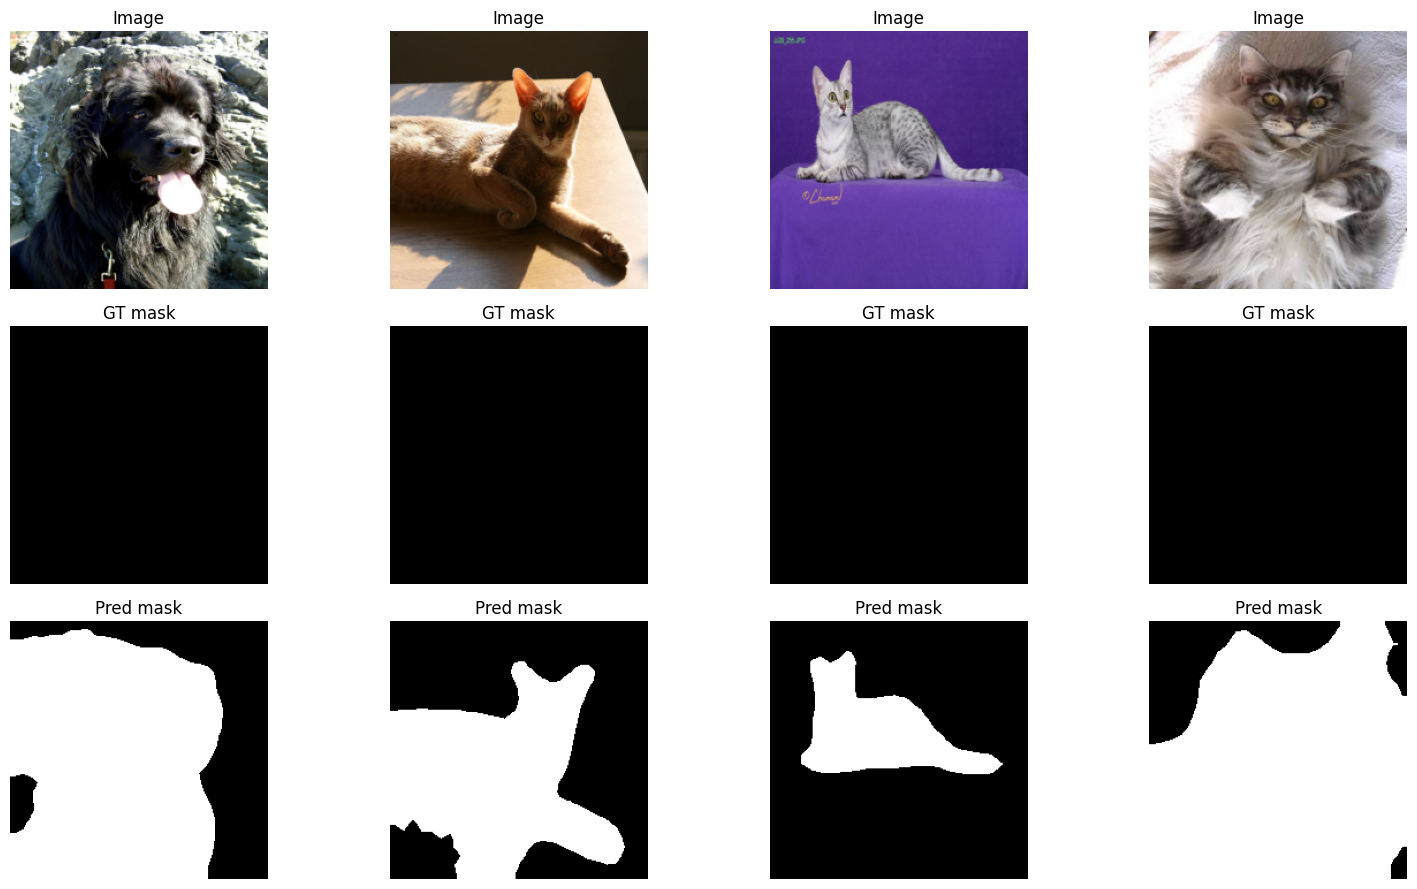

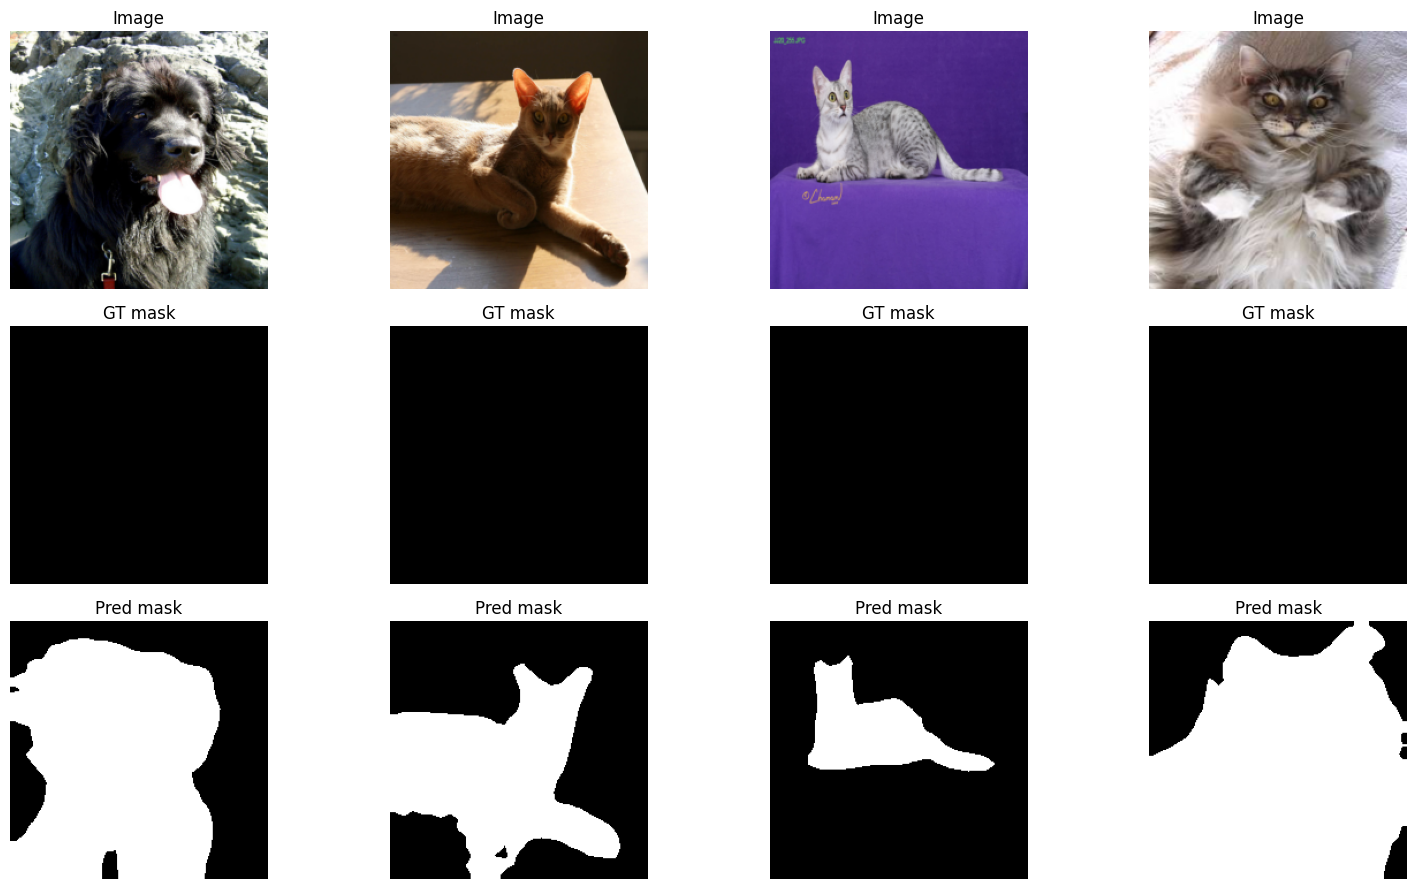

In [43]:
fig_v1 = visualize_segmentation_examples(
    seg_model, val_pet_loader, device, threshold=V1_THRESHOLD, n_batches=2
)
fig_v1.savefig(FIGURES_DIR / "segmentation_examples_v1.png", dpi=150)
plt.show()

fig_v2 = visualize_segmentation_examples(
    seg_model, val_pet_loader, device, threshold=V2_THRESHOLD, n_batches=2
)
fig_v2.savefig(FIGURES_DIR / "segmentation_examples_v2.png", dpi=150)
plt.show()


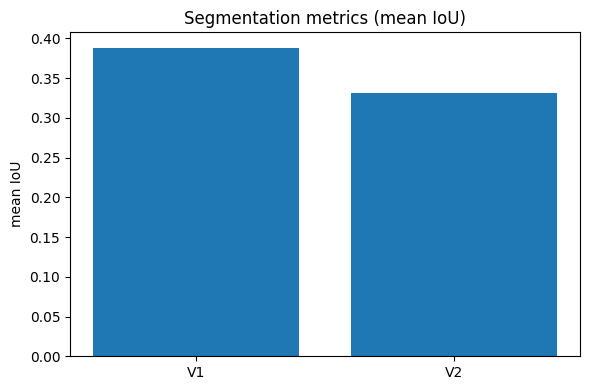

In [44]:
plt.figure(figsize=(6, 4))
x = ["V1", "V2"]
miou_vals = [mean_iou_v1, mean_iou_v2]
plt.bar(x, miou_vals)
plt.ylabel("mean IoU")
plt.title("Segmentation metrics (mean IoU)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150)
plt.show()


In [45]:
import csv

runs_path = ARTIFACTS_DIR / "runs.csv"

fieldnames = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]

with open(runs_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    # C1–C4
    for exp_id, cfg in classification_results.items():
        res = cfg["result"]
        if exp_id == "C1":
            lr = C1_LR
            epochs = C1_EPOCHS
        elif exp_id == "C2":
            lr = C2_LR
            epochs = C2_EPOCHS
        elif exp_id == "C3":
            lr = C3_LR
            epochs = C3_EPOCHS
        else:
            lr = C4_LR
            epochs = C4_EPOCHS

        writer.writerow({
            "experiment_id": exp_id,
            "task": "classification",
            "dataset": "STL10",
            "seed": SEED,
            "model_summary": cfg["model_summary"],
            "optimizer": "Adam",
            "lr": lr,
            "epochs_trained": epochs,
            "best_val_accuracy": res["best_val_acc"],
            "test_accuracy": test_acc_best if exp_id == best_exp_id else "",
            "precision": "",
            "recall": "",
            "mean_iou": "",
            "notes": "",
        })

    # V1
    writer.writerow({
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained, threshold=0.5",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": precision_v1,
        "recall": recall_v1,
        "mean_iou": mean_iou_v1,
        "notes": "V1: base postprocessing",
    })

    # V2
    writer.writerow({
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50 pretrained, threshold=0.7",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": precision_v2,
        "recall": recall_v2,
        "mean_iou": mean_iou_v2,
        "notes": "V2: alternative threshold",
    })

print("Saved runs.csv to", runs_path)


Saved runs.csv to artifacts/runs.csv


In [50]:
!zip -r artifacts.zip artifacts

updating: artifacts/ (stored 0%)
updating: artifacts/checkpoints/ (stored 0%)
updating: artifacts/checkpoints/c4_last.pt (deflated 8%)
updating: artifacts/checkpoints/c2_last.pt (deflated 6%)
updating: artifacts/checkpoints/c3_last.pt (deflated 7%)
updating: artifacts/checkpoints/c1_last.pt (deflated 6%)
updating: artifacts/runs.csv (deflated 52%)
updating: artifacts/figures/ (stored 0%)
updating: artifacts/figures/augmentations_preview.png (deflated 6%)
updating: artifacts/figures/segmentation_examples_v2.png (deflated 2%)
updating: artifacts/figures/classification_compare.png (deflated 24%)
updating: artifacts/figures/segmentation_metrics.png (deflated 24%)
updating: artifacts/figures/classification_curves_best.png (deflated 10%)
updating: artifacts/figures/segmentation_examples.png (deflated 2%)
updating: artifacts/figures/segmentation_examples_v1.png (deflated 2%)
updating: artifacts/best_classifier_config.json (deflated 37%)
updating: artifacts/best_classifier.pt (deflated 7%)


In [51]:
from google.colab import files
files.download("artifacts.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>